# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [4]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  6785k      0 --:--:--  0:02:12 --:--:-- 3860k


In [5]:
!rm SUSY.csv

In [6]:
!gunzip SUSY.csv.gz

In [7]:
ls -lh

total 6794992
-rw-r--r--@ 1 nithyasripaleti  staff    18K Jan  5 21:58 _.jpeg
-rw-r--r--@ 1 nithyasripaleti  staff   162B Oct 21 15:44 ~$. Rhetorical Analysis Essay (RAE) Peer Review Sheet.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 11 19:49 ~$25-SPRING_2252-BIOL-1441-027.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 10 21:10 ~$25-SPRING_2252-DATA-3311-001 (3).docx
-rw-r--r--@ 1 nithyasripaleti  staff   614K Mar  5 07:18 1.1-1.2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   840K Mar  5 07:18 1.3-2.1.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   1.0M Mar 26 15:03 1402.4735v2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  5 07:18 2.3 (1).pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  4 08:29 2.3.pdf
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:23 2025-FALL_2258-BIOL-1441-005 (1).docx
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:20 2025-FALL_2258-BIOL-1441-005.docx
-rw-r--r--@ 1 nithyasripaleti  staff    89K Mar 20 17:35 2025-FALL_2258-DATA-3421-001

The data is provided as a comma separated file.

In [16]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [17]:
!ls -lh

total 6808520
-rw-r--r--@ 1 nithyasripaleti  staff    18K Jan  5 21:58 _.jpeg
-rw-r--r--@ 1 nithyasripaleti  staff   162B Oct 21 15:44 ~$. Rhetorical Analysis Essay (RAE) Peer Review Sheet.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 11 19:49 ~$25-SPRING_2252-BIOL-1441-027.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 10 21:10 ~$25-SPRING_2252-DATA-3311-001 (3).docx
-rw-r--r--@ 1 nithyasripaleti  staff   614K Mar  5 07:18 1.1-1.2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   840K Mar  5 07:18 1.3-2.1.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   1.0M Mar 26 15:03 1402.4735v2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  5 07:18 2.3 (1).pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  4 08:29 2.3.pdf
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:23 2025-FALL_2258-BIOL-1441-005 (1).docx
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:20 2025-FALL_2258-BIOL-1441-005.docx
-rw-r--r--@ 1 nithyasripaleti  staff    89K Mar 20 17:35 2025-FALL_2258-DATA-3421-001

We see that we have 5 million datapoints.

In [18]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [19]:
!head -500000 SUSY.csv > SUSY-small.csv

In [20]:
ls -lh

total 6807880
-rw-r--r--@ 1 nithyasripaleti  staff    18K Jan  5 21:58 _.jpeg
-rw-r--r--@ 1 nithyasripaleti  staff   162B Oct 21 15:44 ~$. Rhetorical Analysis Essay (RAE) Peer Review Sheet.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 11 19:49 ~$25-SPRING_2252-BIOL-1441-027.docx
-rw-r--r--@ 1 nithyasripaleti  staff   162B Dec 10 21:10 ~$25-SPRING_2252-DATA-3311-001 (3).docx
-rw-r--r--@ 1 nithyasripaleti  staff   614K Mar  5 07:18 1.1-1.2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   840K Mar  5 07:18 1.3-2.1.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   1.0M Mar 26 15:03 1402.4735v2.pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  5 07:18 2.3 (1).pdf
-rw-r--r--@ 1 nithyasripaleti  staff   295K Mar  4 08:29 2.3.pdf
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:23 2025-FALL_2258-BIOL-1441-005 (1).docx
-rw-r--r--@ 1 nithyasripaleti  staff    21K Jan 11 12:20 2025-FALL_2258-BIOL-1441-005.docx
-rw-r--r--@ 1 nithyasripaleti  staff    89K Mar 20 17:35 2025-FALL_2258-DATA-3421-001

In [8]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [9]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [10]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [11]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [12]:
FeatureNames

['S_R',
 'cos_theta_r1',
 'R',
 'M_TR_2',
 'MT2',
 'M_R',
 'dPhi_r_b',
 'M_Delta_R',
 'axial_MET',
 'MET_rel']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [14]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [20]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [15]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


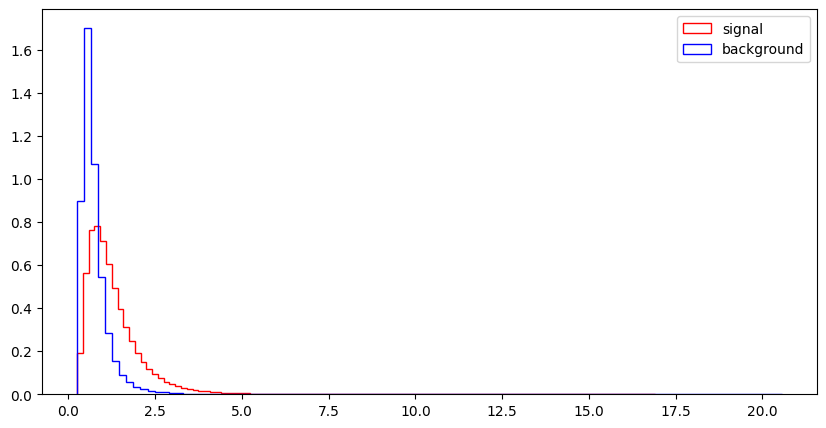

l_1_eta


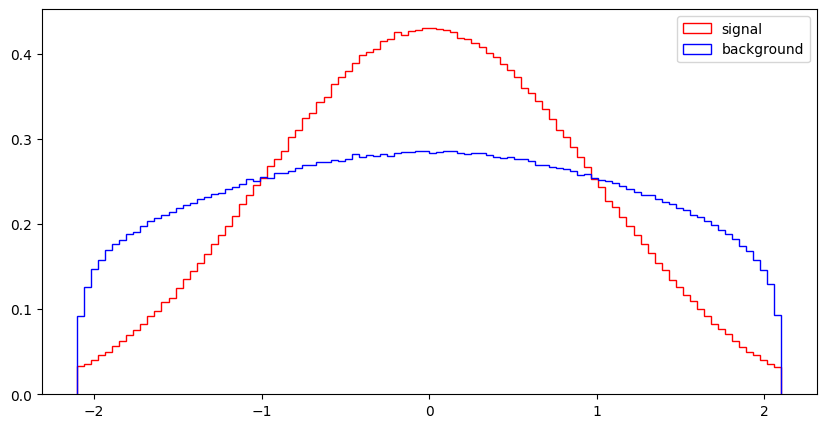

l_1_phi


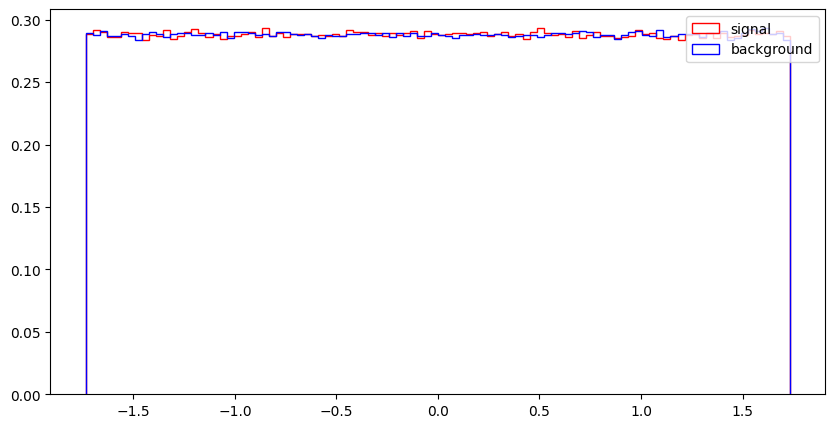

l_2_pT


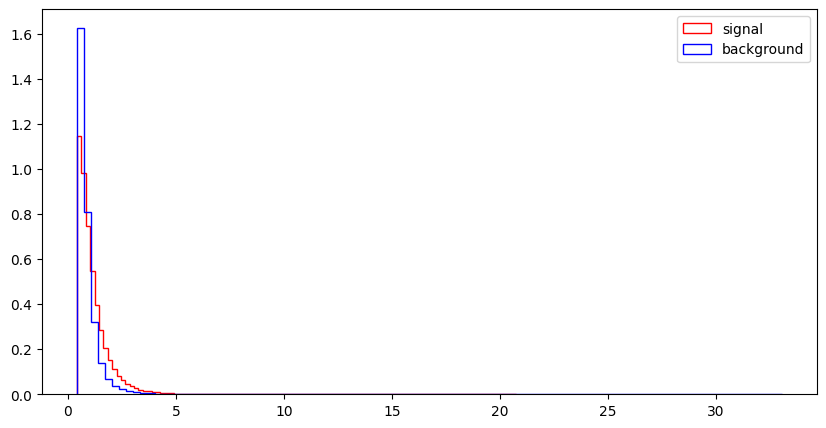

l_2_eta


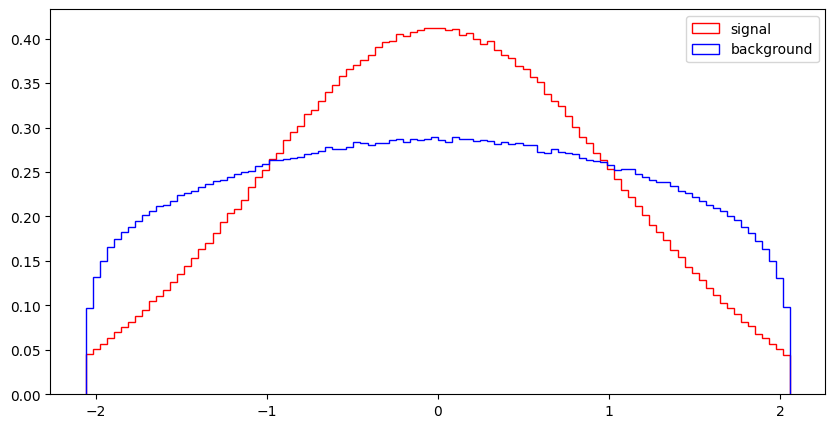

l_2_phi


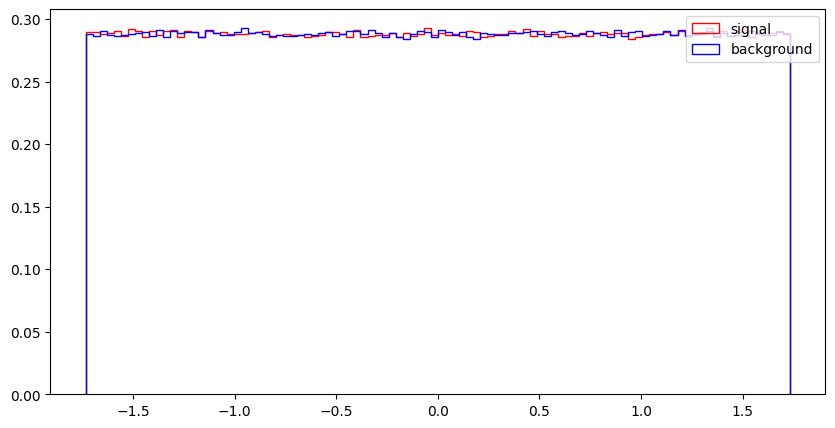

MET


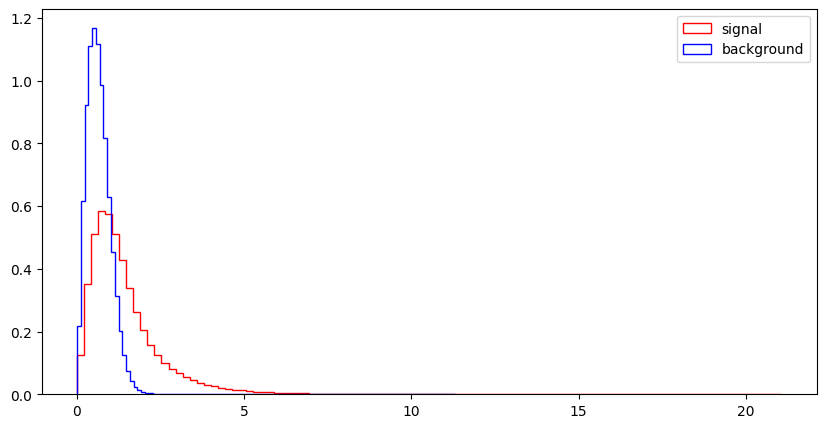

MET_phi


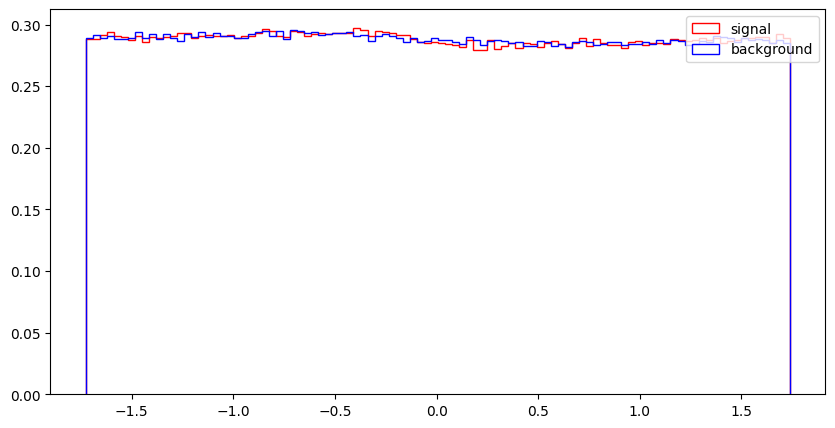

MET_rel


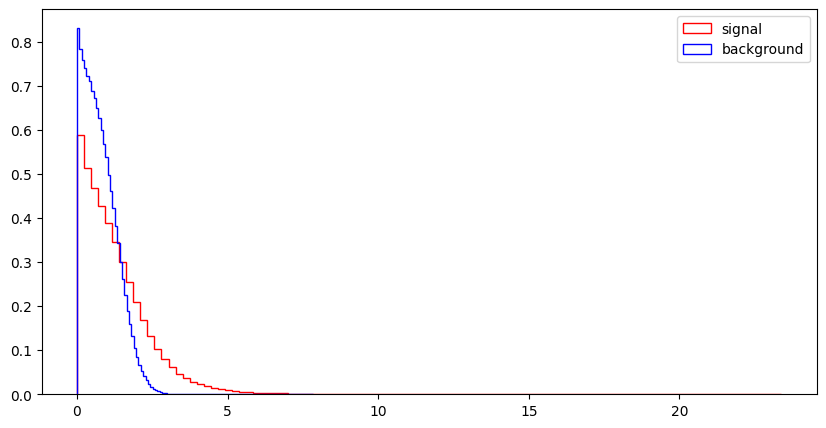

axial_MET


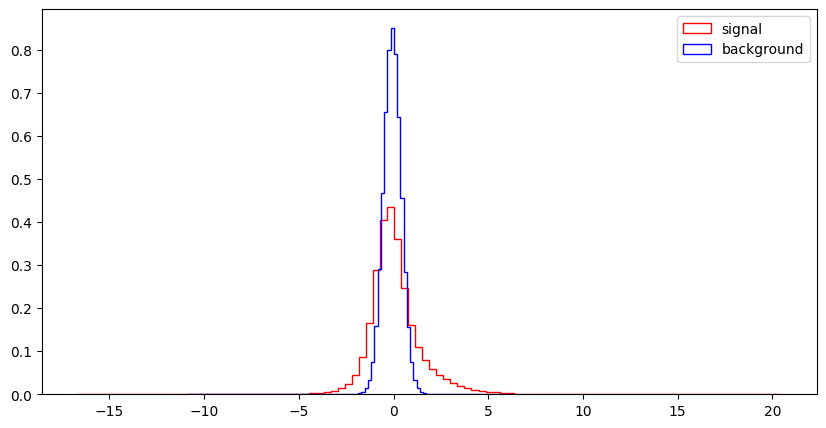

M_R


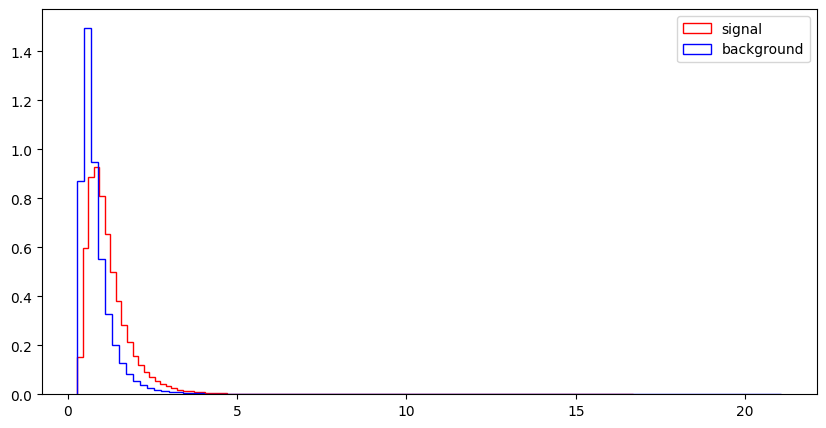

M_TR_2


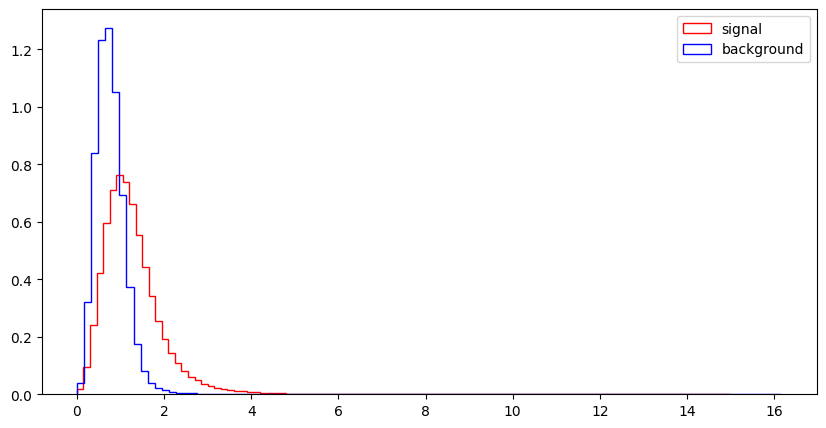

R


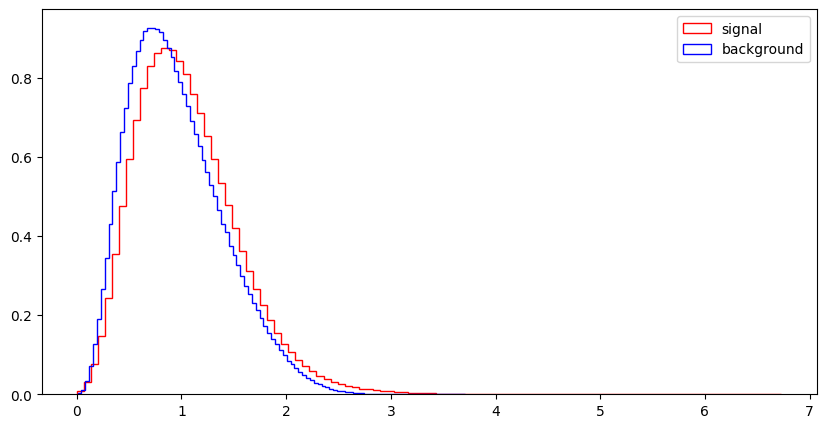

MT2


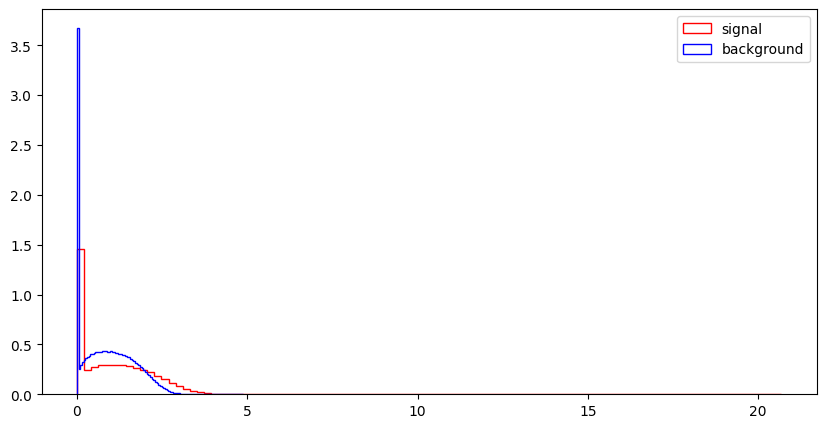

S_R


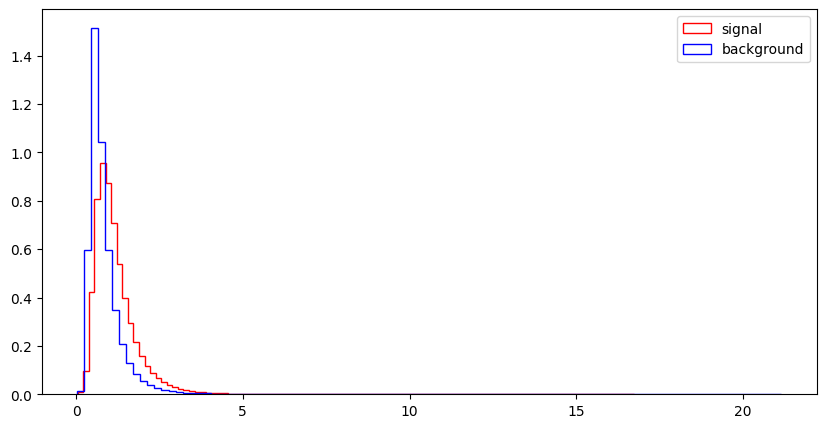

M_Delta_R


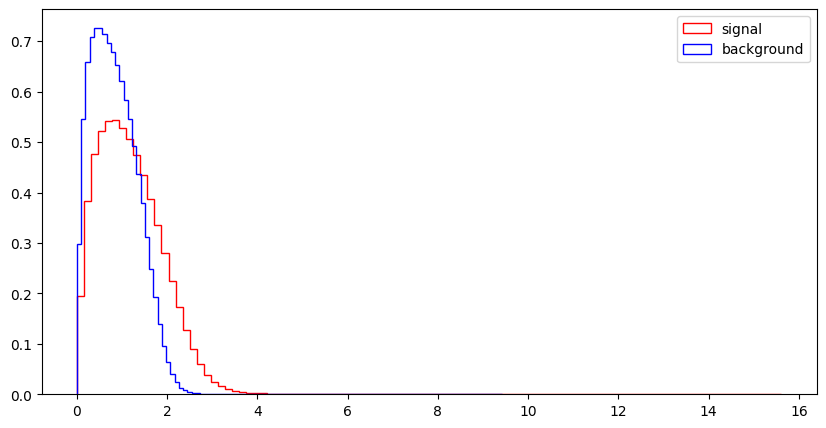

dPhi_r_b


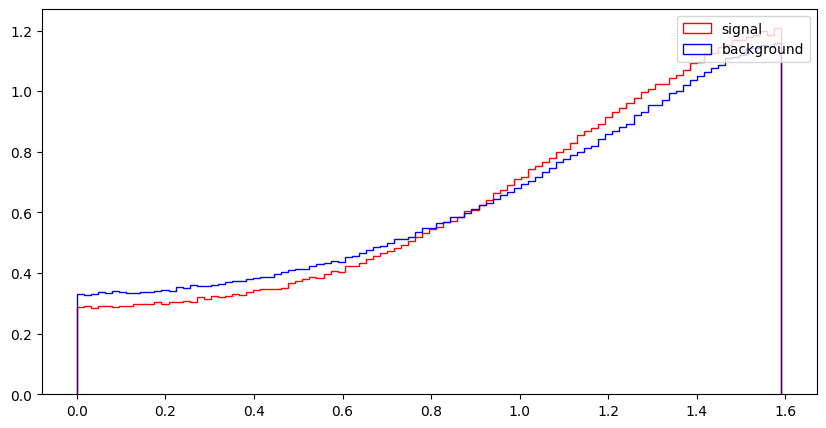

cos_theta_r1


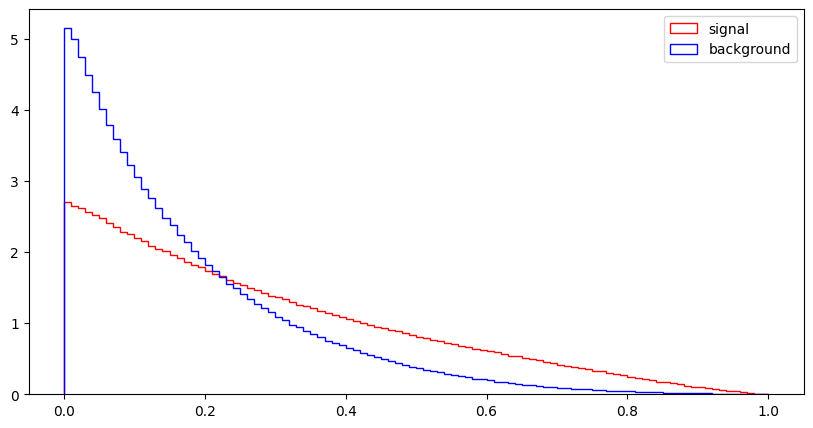

In [16]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

The dataset contains simulated events labeled as signal or background.  
Each event is described by low-level detector/kinematic quantities and higher-level engineered features.  
For the rest of the lab, the main goal is to identify observables and combinations of observables that best separate signal from background.

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

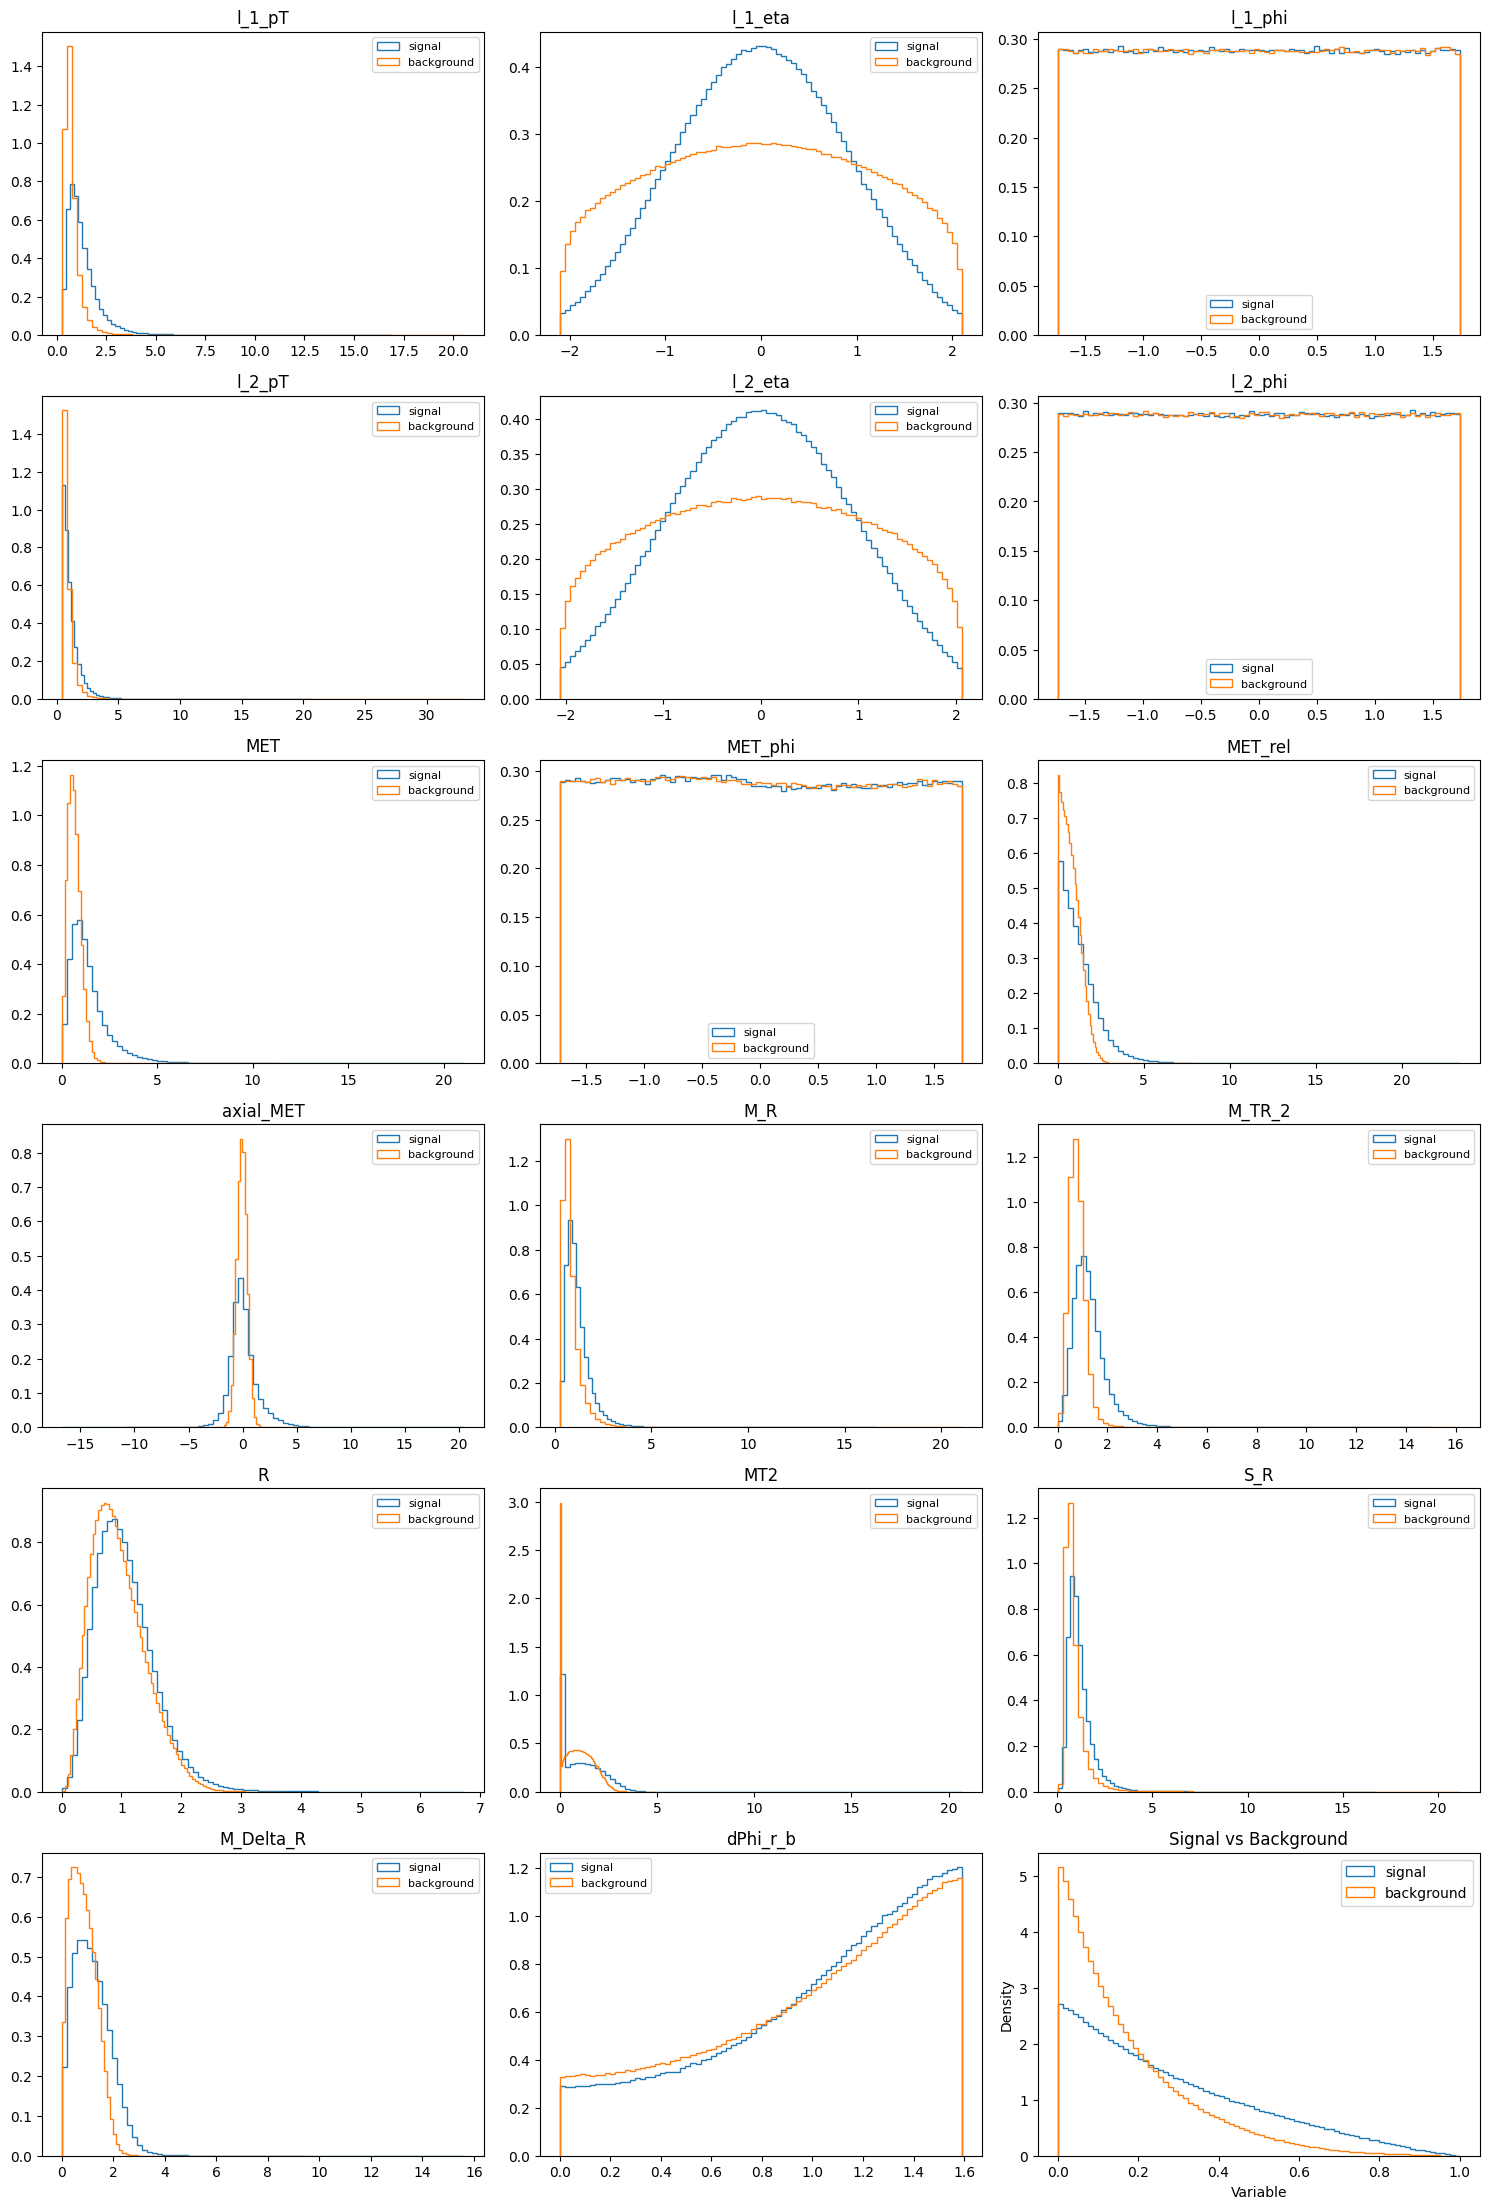

In [17]:
plot_vars = ["l_1_pT", "l_1_eta", "l_1_phi",
             "l_2_pT", "l_2_eta", "l_2_phi",
             "MET", "MET_phi",
             "MET_rel", "axial_MET", "M_R", "M_TR_2",
             "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

fig, axes = plt.subplots(6, 3, figsize=(15, 22))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    axes[i].hist(df_sig[var], bins=80, histtype="step", density=True, label="signal")
    axes[i].hist(df_bkg[var], bins=80, histtype="step", density=True, label="background")
    axes[i].set_title(var)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.xlabel("Variable")
plt.ylabel("Density")
plt.title("Signal vs Background")
plt.legend()
plt.show()

From the plots, we can see that some variables show clear differences between signal and background distributions. 
For example, certain variables have peaks at different ranges for signal compared to background.These differences are useful because 
they allow us to design cuts that separate signal events from background stuff.

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [21]:
def pair_plot_manual(data, variables, sample_size=3000, bins=40):
    sample = data.sample(sample_size, random_state=1)
    sig = sample[sample.signal == 1]
    bkg = sample[sample.signal == 0]

    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                ax.hist(sig[variables[i]], bins=bins, histtype="step", density=True, label="signal")
                ax.hist(bkg[variables[i]], bins=bins, histtype="step", density=True, label="background")
            else:
                ax.scatter(sig[variables[j]], sig[variables[i]], s=2, alpha=0.3, label="signal")
                ax.scatter(bkg[variables[j]], bkg[variables[i]], s=2, alpha=0.3, label="background")

            if i == n - 1:
                ax.set_xlabel(variables[j])
            if j == 0:
                ax.set_ylabel(variables[i])

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles[:2], labels[:2], loc="upper right")
    plt.tight_layout()
    plt.show()

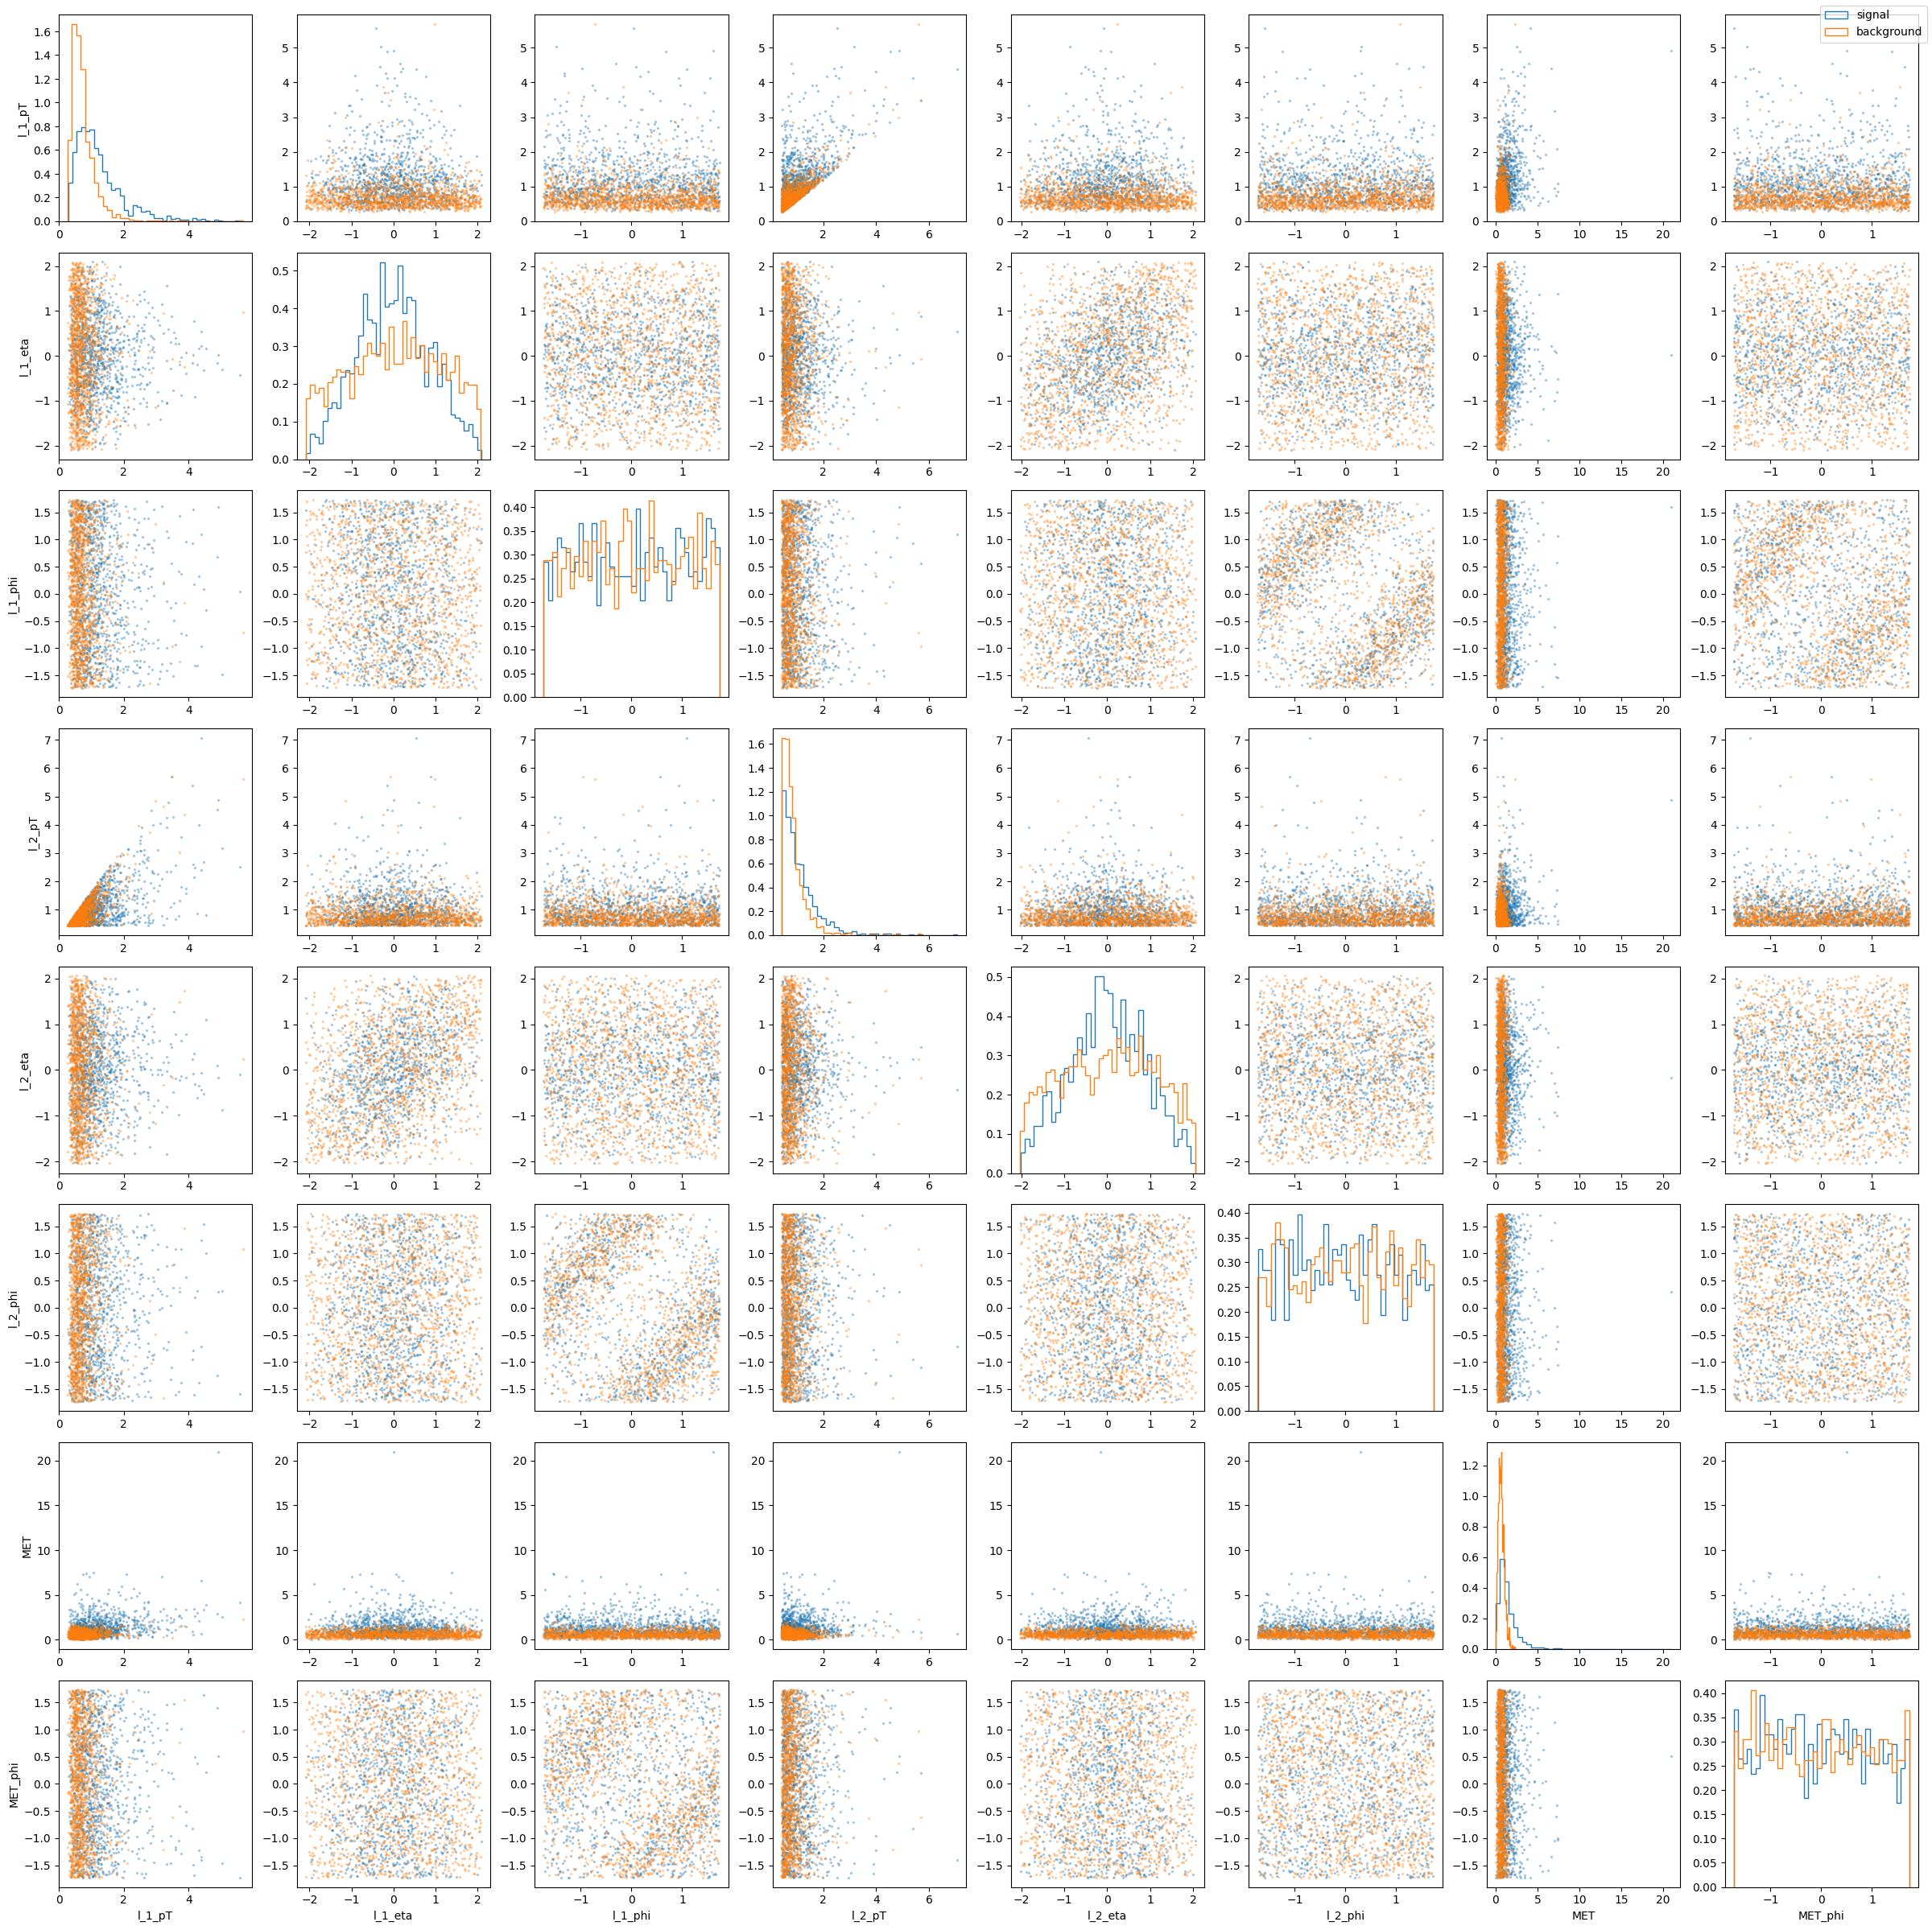

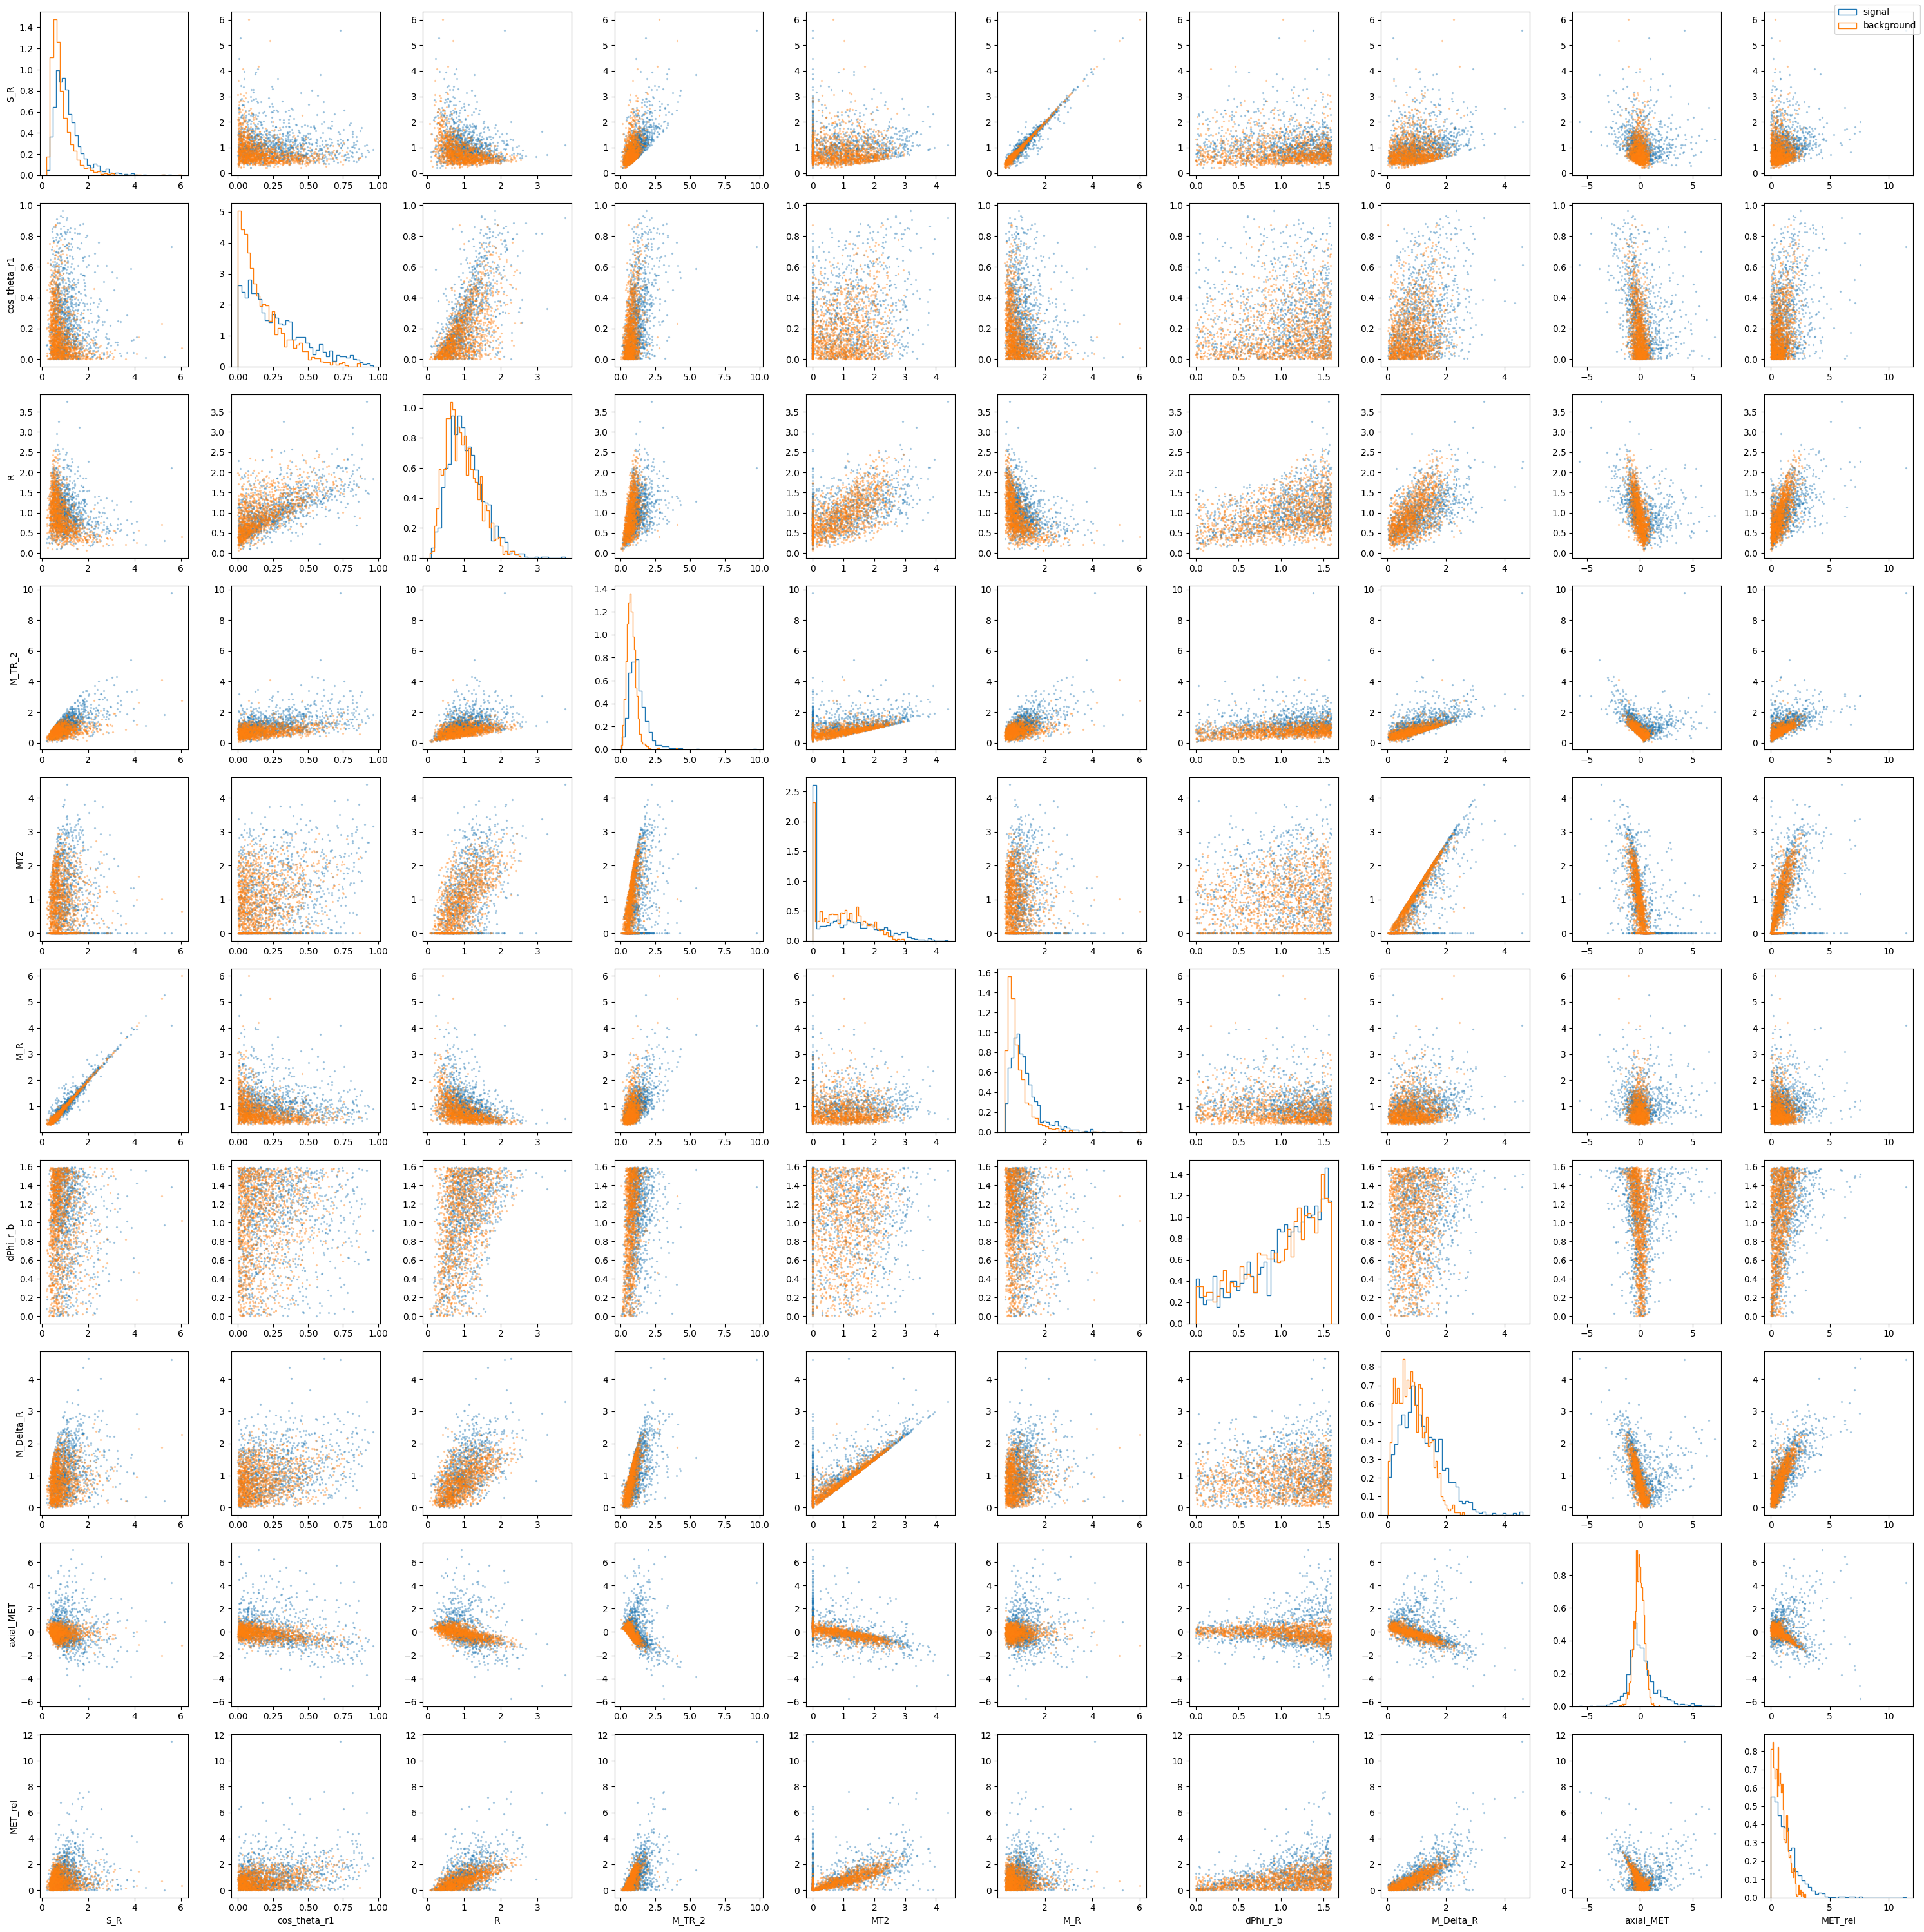

In [22]:
pair_plot_manual(df, RawNames, sample_size=2500)
pair_plot_manual(df, FeatureNames, sample_size=2500)

The pair plots show how signal and background are distributed across pairs of variables. In some cases, the two classes are well 
separated, while in others they overlap significantly.

Interpretation: the most useful observables are the ones whose 1D histograms show clear shape differences between signal and background and 
whose 2D scatter plots show visibly different populations.
High-level variables usually separate better because they encode physics-motivated combinations of raw observables.

In [23]:
def pair_plot_faster(data, variables, sample_size=1500, bins=30):
    sample = data.sample(sample_size, random_state=1).copy()

    arrays = {}
    for var in variables:
        arrays[var] = sample[var].values

    labels = sample["signal"].values
    sig_mask = labels == 1
    bkg_mask = labels == 0

    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                ax.hist(arrays[variables[i]][sig_mask], bins=bins, histtype="step", density=True)
                ax.hist(arrays[variables[i]][bkg_mask], bins=bins, histtype="step", density=True)
            else:
                ax.scatter(arrays[variables[j]][sig_mask], arrays[variables[i]][sig_mask], s=2, alpha=0.25)
                ax.scatter(arrays[variables[j]][bkg_mask], arrays[variables[i]][bkg_mask], s=2, alpha=0.25)

            if i == n - 1:
                ax.set_xlabel(variables[j])
            if j == 0:
                ax.set_ylabel(variables[i])

    plt.tight_layout()
    plt.show()

To make the pair plots faster, I used a smaller random sample and converted each variable into a numpy array before plotting. 
This reduces repeated dataframe indexing inside the nested loops.

Exercise 4.1(c) interpretation

The observables that appear best for separating signal from background are typically among the high-level features, because their signal and background histograms tend to differ in both location and shape. In contrast, angular variables such as `l_1_phi`, `l_2_phi`, and `MET_phi` usually show strong overlap and therefore provide weak standalone discrimination.

When you run the updated ranking code below, use the actual top few variables from your output and mention them explicitly here. A strong answer should name the best variables, note that they are mostly engineered/high-level features, and contrast them with the weakest overlapping variables.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [32]:
pip install tabulate


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Hint: Example code for embedding a `tabulate` table into a notebook:

In [24]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


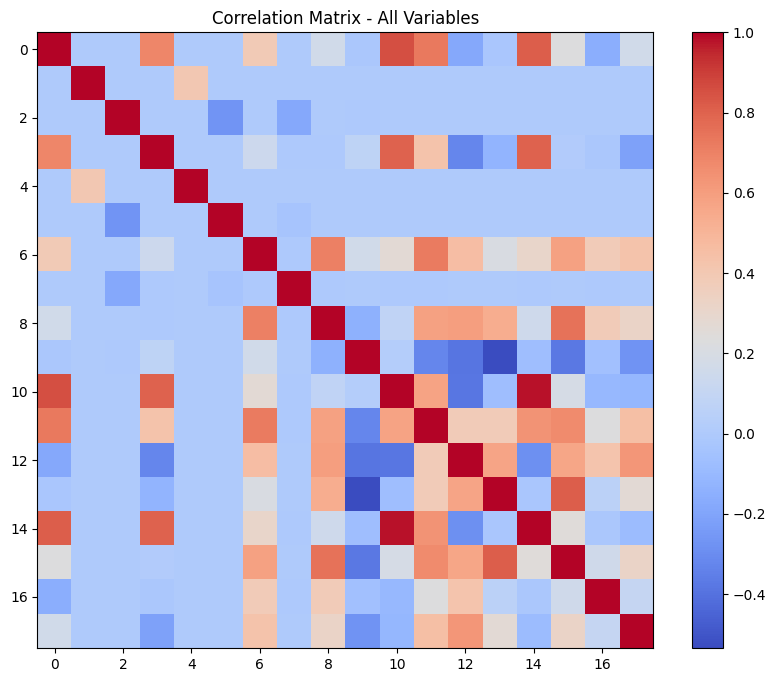

In [25]:
corr_all = np.corrcoef(df[VarNames[1:]].values, rowvar=False)
cov_all = np.cov(df[VarNames[1:]].values, rowvar=False)

plt.figure(figsize=(10,8))
plt.imshow(corr_all, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Matrix - All Variables")
plt.show()

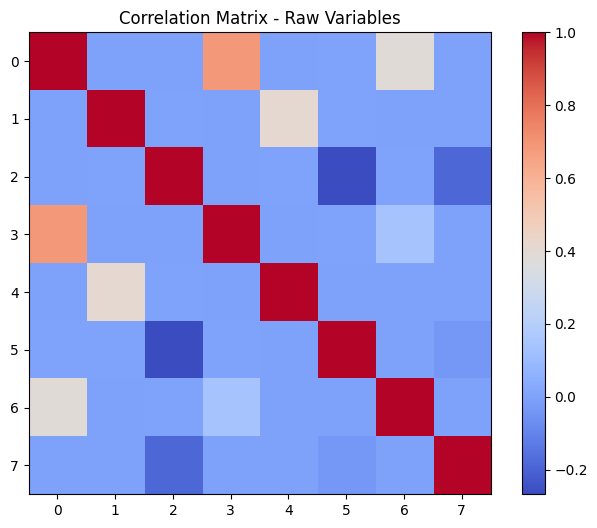

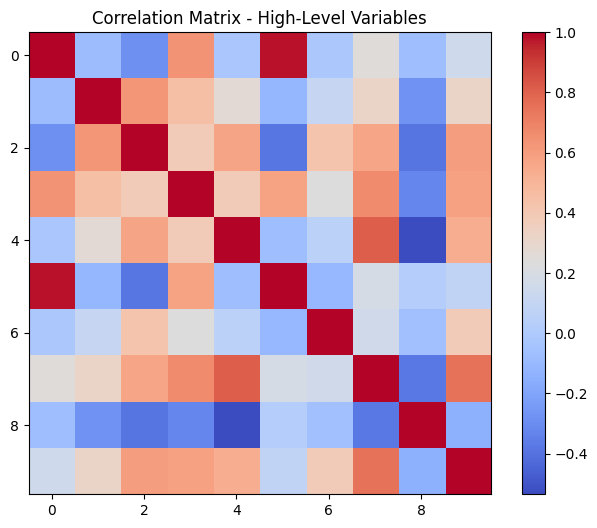

In [26]:
corr_raw = np.corrcoef(df[RawNames].values, rowvar=False)
corr_feat = np.corrcoef(df[FeatureNames].values, rowvar=False)

plt.figure(figsize=(8,6))
plt.imshow(corr_raw, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Matrix - Raw Variables")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(corr_feat, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Matrix - High-Level Variables")
plt.show()

In [19]:
## The correlation matrix helps us understand how different variables are related to each other so highly correlated variables provide 
# similar information, while uncorrelated variables may provide independent features. This is important because using too many correlated 
# variables doesnt necessarily improve performance significantly (and might be redundant)

The correlation matrices identify which observables carry overlapping information.  
A large correlation magnitude means two variables are strongly related, so using both in a cut-based selection may add less new information than expected.  
Looking back, that actually matters later in the cut-flow part of the lab, because picking several individually strong but highly correlated variables can be less effective than mixing strong and relatively independent observables.

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [27]:
def get_efficiencies(values_sig, values_bkg, cut, mode):
    if mode == "greater":
        eps_s = np.mean(values_sig > cut)
        eps_b = np.mean(values_bkg > cut)
    elif mode == "less":
        eps_s = np.mean(values_sig < cut)
        eps_b = np.mean(values_bkg < cut)
    elif mode == "abs_greater":
        eps_s = np.mean(np.abs(values_sig) > cut)
        eps_b = np.mean(np.abs(values_bkg) > cut)
    elif mode == "abs_less":
        eps_s = np.mean(np.abs(values_sig) < cut)
        eps_b = np.mean(np.abs(values_bkg) < cut)
    else:
        raise ValueError("Invalid mode")
    return eps_s, eps_b

In [28]:
def significance(eps_s, eps_b, N_sig, N_bkg):
    Nsig_prime = eps_s * N_sig
    Nbkg_prime = eps_b * N_bkg
    if Nsig_prime + Nbkg_prime == 0:
        return 0
    return Nsig_prime / np.sqrt(Nsig_prime + Nbkg_prime)

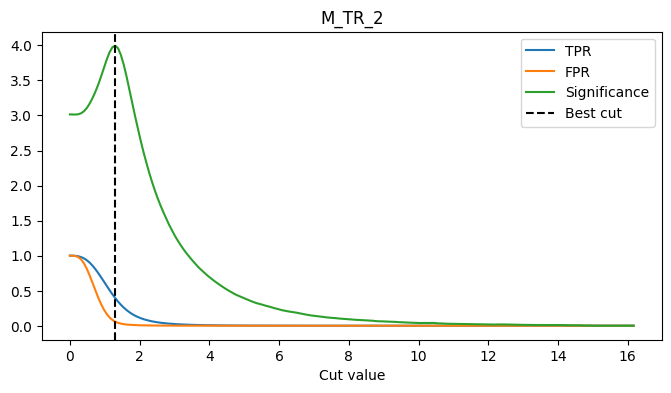

Best cut = 1.3008023778745323
Best significance = 3.995114440154911


In [29]:
var = "M_TR_2"
x_sig = df_sig[var].values
x_bkg = df_bkg[var].values

cuts = np.linspace(min(x_sig.min(), x_bkg.min()),
                   max(x_sig.max(), x_bkg.max()), 200)

tpr = []
fpr = []
sig_vals = []

N_sig = 100
N_bkg = 1000

for c in cuts:
    eps_s = np.mean(x_sig > c)
    eps_b = np.mean(x_bkg > c)

    tpr.append(eps_s)
    fpr.append(eps_b)

    Ns = eps_s * N_sig
    Nb = eps_b * N_bkg
    if Ns + Nb > 0:
        sig_vals.append(Ns / np.sqrt(Ns + Nb))
    else:
        sig_vals.append(0)

best_i = np.argmax(sig_vals)

plt.figure(figsize=(8,4))
plt.plot(cuts, tpr, label="TPR")
plt.plot(cuts, fpr, label="FPR")
plt.plot(cuts, sig_vals, label="Significance")
plt.axvline(cuts[best_i], color="black", linestyle="--", label="Best cut")
plt.title("M_TR_2")
plt.xlabel("Cut value")
plt.legend()
plt.show()

print("Best cut =", cuts[best_i])
print("Best significance =", sig_vals[best_i])

In [21]:
## From the plots, I can identify the cut value that maximizes the significance. This represents the best trade-off between retaining 
# signal events and rejecting background events.Different variables have different optimal cut points depending on how well 
# they separate signal and background.

In [30]:
#5.2

scenarios = {
    "1": (10, 100),
    "2": (100, 1000),
    "2.1": (200, 2000),
    "2.2": (300, 3000),
    "2.3": (400, 4000),
    "2.4": (500, 5000),
    "3": (1000, 10000),
    "4": (10000, 100000)}

In [31]:

cut_modes = {
    "l_1_pT": "greater",
    "l_1_eta": "abs_less",
    "l_1_phi": "greater",
    "l_2_pT": "greater",
    "l_2_eta": "abs_less",
    "l_2_phi": "greater",
    "MET": "greater",
    "MET_phi": "greater",
    "MET_rel": "greater",
    "axial_MET": "greater",
    "M_R": "greater",
    "M_TR_2": "greater",
    "R": "greater",
    "MT2": "greater",
    "S_R": "greater",
    "M_Delta_R": "greater",
    "dPhi_r_b": "greater",
    "cos_theta_r1": "abs_less"}

In [11]:
## For most of the strongly separating variables, the signal tends to dominate at larger values, so a cut like x > x(c) fits in this situation.


In [32]:
df_sig = df[df["signal"] == 1].copy()
df_bkg = df[df["signal"] == 0].copy()

print(df.shape)
print(df_sig.shape)
print(df_bkg.shape)

#got an error so checked df_sig

(5000000, 19)
(2287827, 19)
(2712173, 19)


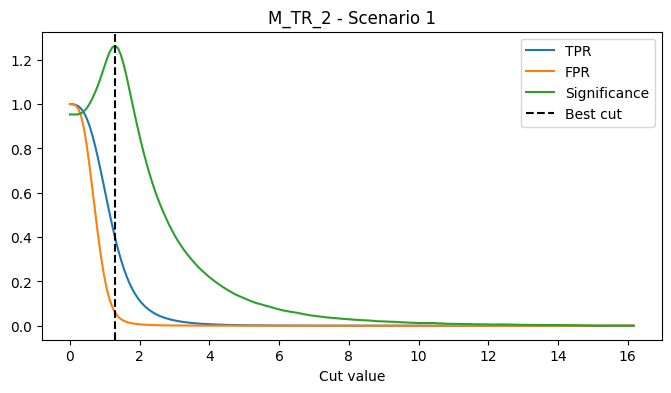

Scenario: 1
Best cut = 1.3008023778745323
Best significance = 1.2633661143917976



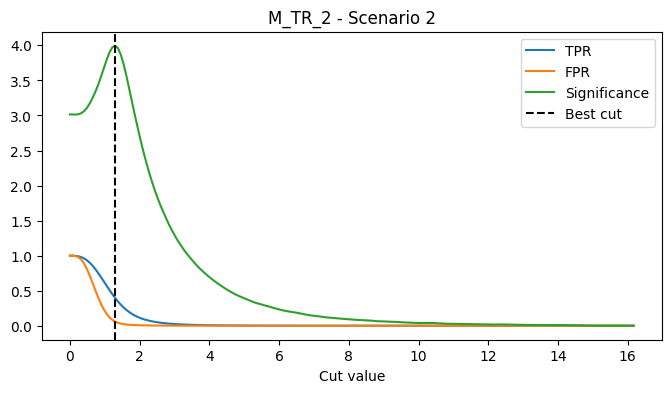

Scenario: 2
Best cut = 1.3008023778745323
Best significance = 3.995114440154911



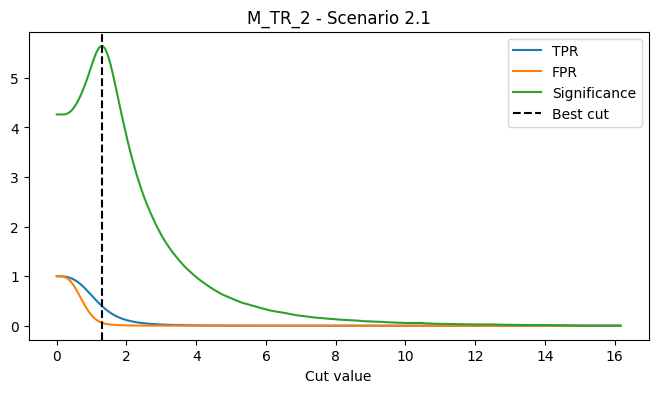

Scenario: 2.1
Best cut = 1.3008023778745323
Best significance = 5.64994502449967



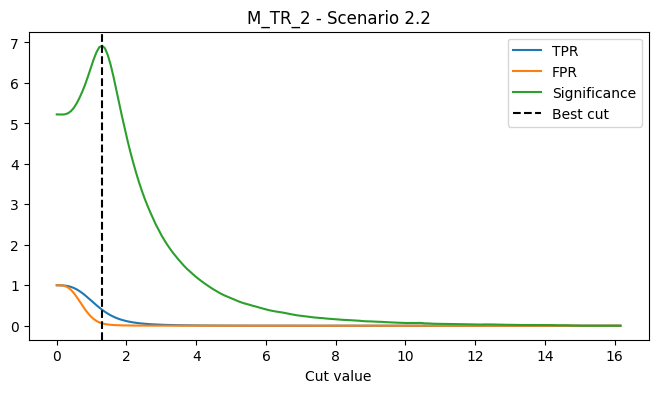

Scenario: 2.2
Best cut = 1.3008023778745323
Best significance = 6.919741192400396



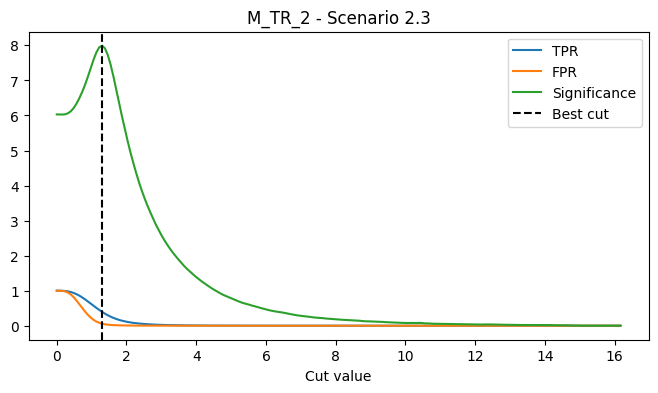

Scenario: 2.3
Best cut = 1.3008023778745323
Best significance = 7.990228880309822



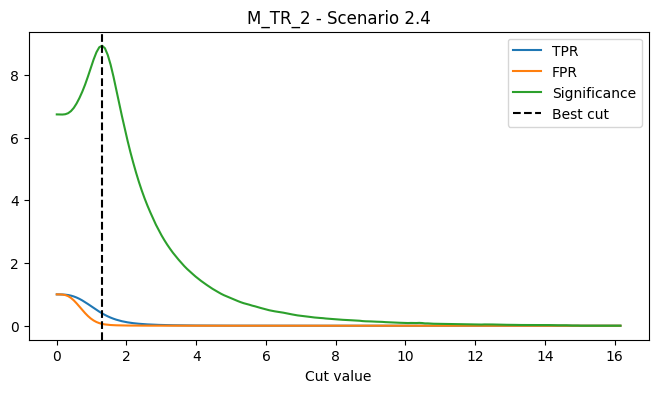

Scenario: 2.4
Best cut = 1.3008023778745323
Best significance = 8.933347466077397



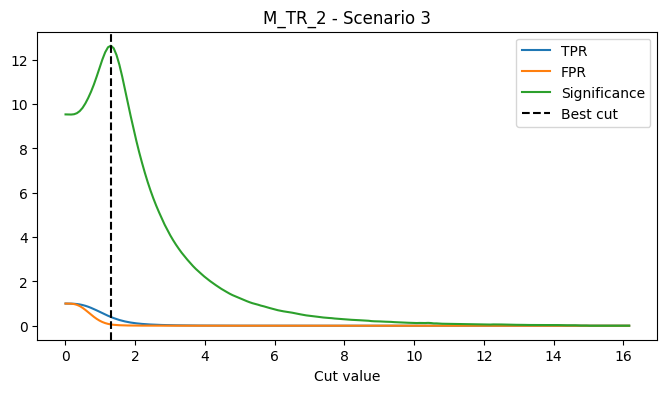

Scenario: 3
Best cut = 1.3008023778745323
Best significance = 12.633661143917974



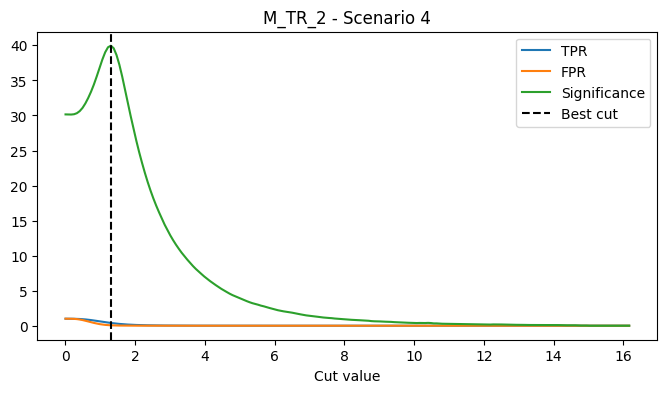

Scenario: 4
Best cut = 1.3008023778745323
Best significance = 39.951144401549115



In [36]:
var = "M_TR_2"
mode = cut_modes[var]

def apply_mode(values, cut, mode):
    if mode == "greater":
        return values > cut
    elif mode == "less":
        return values < cut
    elif mode == "abs_greater":
        return np.abs(values) > cut
    elif mode == "abs_less":
        return np.abs(values) < cut
    else:
        raise ValueError("Invalid mode")

for scenario_name, (N_sig, N_bkg) in scenarios.items():
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    all_vals = np.concatenate([x_sig, x_bkg])
    cuts = np.linspace(all_vals.min(), all_vals.max(), 200)

    TPR = []
    FPR = []
    sig_vals = []

    for cut in cuts:
        mask_sig = apply_mode(x_sig, cut, mode)
        mask_bkg = apply_mode(x_bkg, cut, mode)

        eps_s = np.mean(mask_sig)
        eps_b = np.mean(mask_bkg)

        Ns = eps_s * N_sig
        Nb = eps_b * N_bkg

        TPR.append(eps_s)
        FPR.append(eps_b)

        if Ns + Nb > 0:
            sig_vals.append(Ns / np.sqrt(Ns + Nb))
        else:
            sig_vals.append(0)

    TPR = np.array(TPR)
    FPR = np.array(FPR)
    sig_vals = np.array(sig_vals)

    best_i = np.argmax(sig_vals)

    plt.figure(figsize=(8,4))
    plt.plot(cuts, TPR, label="TPR")
    plt.plot(cuts, FPR, label="FPR")
    plt.plot(cuts, sig_vals, label="Significance")
    plt.axvline(cuts[best_i], color="black", linestyle="--", label="Best cut")
    plt.title(f"{var} - Scenario {scenario_name}")
    plt.xlabel("Cut value")
    plt.legend()
    plt.show()

    print("Scenario:", scenario_name)
    print("Best cut =", cuts[best_i])
    print("Best significance =", sig_vals[best_i])
    print()

In [37]:
rows = []

for var in VarNames[1:]:
    mode = cut_modes[var]
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    if "abs" in mode:
        xmax = max(np.max(np.abs(x_sig)), np.max(np.abs(x_bkg)))
        cuts = np.linspace(0, xmax, 100)
    else:
        cuts = np.linspace(min(x_sig.min(), x_bkg.min()),
                           max(x_sig.max(), x_bkg.max()), 100)

    best_sig = 0
    best_cut = 0
    best_tpr = 0
    best_fpr = 0

    for c in cuts:
        if mode == "greater":
            eps_s = np.mean(x_sig > c)
            eps_b = np.mean(x_bkg > c)
        elif mode == "less":
            eps_s = np.mean(x_sig < c)
            eps_b = np.mean(x_bkg < c)
        elif mode == "abs_greater":
            eps_s = np.mean(np.abs(x_sig) > c)
            eps_b = np.mean(np.abs(x_bkg) > c)
        elif mode == "abs_less":
            eps_s = np.mean(np.abs(x_sig) < c)
            eps_b = np.mean(np.abs(x_bkg) < c)

        Ns = eps_s * 100
        Nb = eps_b * 1000

        if Ns + Nb > 0:
            sig = Ns / np.sqrt(Ns + Nb)

            if sig > best_sig:
                best_sig = sig
                best_cut = c
                best_tpr = eps_s
                best_fpr = eps_b

    rows.append([var, mode, best_cut, best_tpr, best_fpr, best_sig])

results_s2 = pd.DataFrame(rows, columns=["variable", "rule", "best_cut", "TPR", "FPR", "sigma"])
results_s2 = results_s2.sort_values("sigma", ascending=False)
results_s2

,variable,rule,best_cut,TPR,FPR,sigma
6,MET,greater,1.489960e+00,0.343829,0.018484,4.728812
11,M_TR_2,greater,1.307367e+00,0.390164,0.056350,3.995290
0,l_1_pT,greater,8.699897e-01,0.656590,0.249908,3.696137
9,axial_MET,greater,1.320900e+00,0.138434,0.002406,3.434213
10,M_R,greater,6.876790e-01,0.798848,0.502327,3.310726
14,S_R,greater,6.674904e-01,0.823908,0.541964,3.297334
1,l_1_eta,abs_less,1.508160e+00,0.917366,0.790066,3.089279
8,MET_rel,greater,2.362267e+00,0.138644,0.006663,3.060092
4,l_2_eta,abs_less,1.622810e+00,0.934410,0.850239,3.041763
3,l_2_pT,greater,4.285860e-01,1.000000,0.999998,3.015116


In [20]:
## We scan different cut values for each variable and compute signal efficiency (TPR), background efficiency (FPR), significance
# The goal is to find a cut that maximizes significance while keeping a high signal efficiency and low background efficiency.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [38]:
def apply_cut(data, variable, mode, cut):
    if mode == "greater":
        return data[data[variable] > cut]
    elif mode == "less":
        return data[data[variable] < cut]
    elif mode == "abs_greater":
        return data[np.abs(data[variable]) > cut]
    elif mode == "abs_less":
        return data[np.abs(data[variable]) < cut]

In [39]:
def cutflow_table(df, cut_list, N_sig, N_bkg):
    current = df.copy()
    total_sig = np.sum(df.signal == 1)
    total_bkg = np.sum(df.signal == 0)

    rows = []

    for step, (var, mode, cut) in enumerate(cut_list, start=1):
        current = apply_cut(current, var, mode, cut)

        sig_now = np.sum(current.signal == 1)
        bkg_now = np.sum(current.signal == 0)

        eps_s = sig_now / total_sig
        eps_b = bkg_now / total_bkg

        Nsig_prime = eps_s * N_sig
        Nbkg_prime = eps_b * N_bkg
        sigma = Nsig_prime / np.sqrt(Nsig_prime + Nbkg_prime) if (Nsig_prime + Nbkg_prime) > 0 else 0

        rows.append([step, var, mode, cut, eps_s, eps_b, Nsig_prime, Nbkg_prime, sigma])

    table = pd.DataFrame(rows, columns=[
        "step", "variable", "rule", "cut", "eps_s", "eps_b", "Nsig_prime", "Nbkg_prime", "sigma"
    ])
    return table

In [42]:
selected = []

for _, row in results_s2.iterrows():
    var = row["variable"]

    if not selected:
        selected.append(var)
        continue

    keep = True
    for s in selected:
        i = VarNames.index(var)
        j = VarNames.index(s)
        if abs(corr_all[i, j]) > 0.8:
            keep = False
            break

    if keep:
        selected.append(var)

    if len(selected) == 3:
        break

print("Selected variables:", selected)

top3 = results_s2[results_s2["variable"].isin(selected)].copy()

top3["order"] = top3["variable"].apply(lambda x: selected.index(x))
top3 = top3.sort_values("order")

cut_list = [(row["variable"], row["rule"], row["best_cut"]) for _, row in top3.iterrows()]

cf = cutflow_table(df, cut_list, 100, 1000)
cf

Selected variables: ['MET', 'M_TR_2', 'l_1_pT']


,step,variable,rule,cut,eps_s,eps_b,Nsig_prime,Nbkg_prime,sigma
0,1,MET,greater,1.489960,0.343829,0.018484,34.382932,18.483703,4.728812
1,2,M_TR_2,greater,1.307367,0.248662,0.013183,24.866172,13.182787,4.031230
2,3,l_1_pT,greater,0.869990,0.211737,0.009431,21.173716,9.430814,3.827403


The cutflow table shows how many events remain after applying each cut sequentially. We can observe that the order of cuts can affect the final number of events, since 
earlier cuts reduce the dataset for later.

In [43]:
cut_list_order1 = cut_list
cut_list_order2 = list(reversed(cut_list))

cf1 = cutflow_table(df, cut_list_order1, 100, 1000)
cf2 = cutflow_table(df, cut_list_order2, 100, 1000)

print("Original order")
display(cf1)

print("Reversed order")
display(cf2)

Original order


,step,variable,rule,cut,eps_s,eps_b,Nsig_prime,Nbkg_prime,sigma
0,1,MET,greater,1.489960,0.343829,0.018484,34.382932,18.483703,4.728812
1,2,M_TR_2,greater,1.307367,0.248662,0.013183,24.866172,13.182787,4.031230
2,3,l_1_pT,greater,0.869990,0.211737,0.009431,21.173716,9.430814,3.827403


Reversed order


,step,variable,rule,cut,eps_s,eps_b,Nsig_prime,Nbkg_prime,sigma
0,1,l_1_pT,greater,0.869990,0.656590,0.249908,65.658986,249.908468,3.696137
1,2,M_TR_2,greater,1.307367,0.346885,0.048869,34.688462,48.869301,3.794824
2,3,MET,greater,1.489960,0.211737,0.009431,21.173716,9.430814,3.827403


When I changed the order of the cuts, the final significance changed. This happens because the observables are not independent.

Changing the cut order can change the final significance because the observables are correlated.  
Once one cut is applied, the surviving population is no longer distributed the same way, so the later cuts act on a different sample.  

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



/var/folders/87/2ddmhzmx6hj6hwln8h1zcyhc0000gn/T/ipykernel_31083/1625138090.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


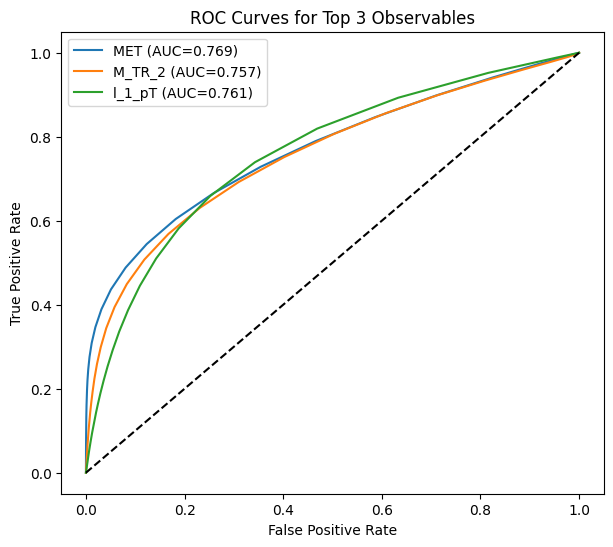

In [44]:
top3_vars = results_s2.head(3)["variable"].tolist()

plt.figure(figsize=(7,6))

for var in top3_vars:
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    cuts = np.linspace(min(x_sig.min(), x_bkg.min()),
                       max(x_sig.max(), x_bkg.max()), 200)

    tpr = []
    fpr = []

    for c in cuts:
        eps_s = np.mean(x_sig > c)
        eps_b = np.mean(x_bkg > c)
        tpr.append(eps_s)
        fpr.append(eps_b)

    fpr = np.array(fpr)
    tpr = np.array(tpr)

    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    auc = np.trapz(tpr, fpr)

    plt.plot(fpr, tpr, label=f"{var} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Top 3 Observables")
plt.legend()
plt.show()

### ROC Curve Interpretation

The ROC curve shows the trade-off between signal efficiency (TPR) and background efficiency (FPR). A curve closer to the top-left corner indicates better performance, as it corresponds to high signal efficiency and low background efficiency. Comparing ROC curves allows to evaluate which variables or methods perform better.

In [45]:
def plot_roc_for_variables(df_sig, df_bkg, variables, cut_modes, title="ROC Curves"):
    plt.figure(figsize=(7, 6))

    for var in variables:
        mode = cut_modes[var]
        FPR, TPR, auc = roc_curve_manual(df_sig[var].values, df_bkg[var].values, mode)
        plt.plot(FPR, TPR, label=f"{var} (AUC={auc:.3f})")

    plt.plot([0,1], [0,1], linestyle="--", color="black")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

In [46]:
def apply_cut_to_sig_bkg(df_sig, df_bkg, variable, mode, cut):
    sig_cut = apply_cut(df_sig, variable, mode, cut)
    bkg_cut = apply_cut(df_bkg, variable, mode, cut)
    return sig_cut, bkg_cut

In [48]:
def apply_mode(values, cut, mode):
    if mode == "greater":
        return values > cut
    elif mode == "less":
        return values < cut
    elif mode == "abs_greater":
        return np.abs(values) > cut
    elif mode == "abs_less":
        return np.abs(values) < cut
    else:
        raise ValueError("Invalid mode")

def roc_curve_manual(x_sig, x_bkg, mode, ncuts=200):
    all_vals = np.concatenate([x_sig, x_bkg])
    cuts = np.linspace(all_vals.min(), all_vals.max(), ncuts)

    FPR = []
    TPR = []

    for c in cuts:
        mask_sig = apply_mode(x_sig, c, mode)
        mask_bkg = apply_mode(x_bkg, c, mode)

        tpr = np.mean(mask_sig)
        fpr = np.mean(mask_bkg)

        TPR.append(tpr)
        FPR.append(fpr)

    FPR = np.array(FPR)
    TPR = np.array(TPR)

    order = np.argsort(FPR)
    FPR = FPR[order]
    TPR = TPR[order]

    auc = np.trapz(TPR, FPR)
    return FPR, TPR, auc

The ROC curve compares the signal efficiency to the background efficiency across all possible cuts.
The best single-variable ROC curve is the one with the largest AUC and the strongest bend toward the top-left corner.  
When you discuss this result, explicitly identify which variable has the largest AUC and compare it to the others in words, not just by showing the figure.

/var/folders/87/2ddmhzmx6hj6hwln8h1zcyhc0000gn/T/ipykernel_31083/1762105706.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(TPR, FPR)


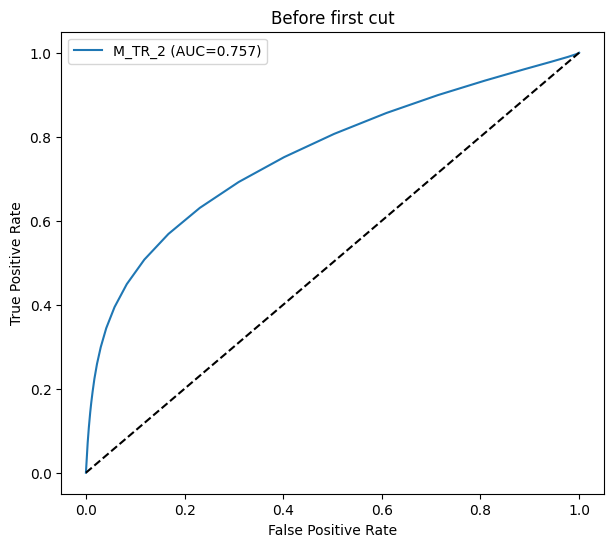

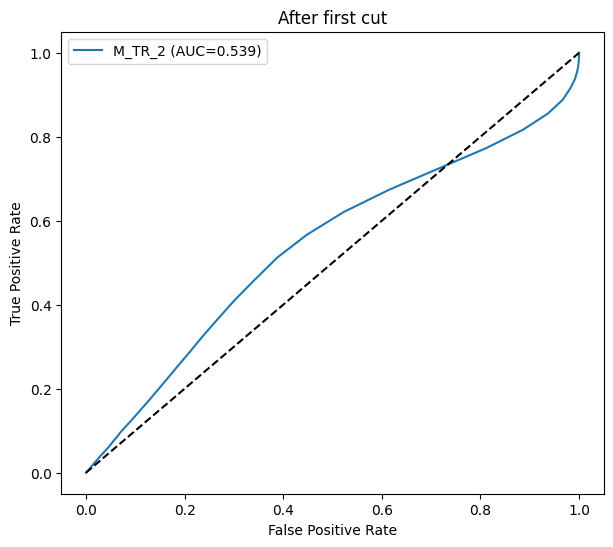

In [49]:
# example with first two cuts
first_var, first_mode, first_cut = cut_list[0]
second_var, second_mode, second_cut = cut_list[1]

# b4 cuts
plot_roc_for_variables(df_sig, df_bkg, [second_var], cut_modes, title="Before first cut")

# after first cut
df_sig_after, df_bkg_after = apply_cut_to_sig_bkg(df_sig, df_bkg, first_var, first_mode, first_cut)
plot_roc_for_variables(df_sig_after, df_bkg_after, [second_var], cut_modes, title="After first cut")

Interpretation: after each successive cut, the ROC curves of the remaining variables can change,
which shows that the variables are not independent. This is another way to see correlation effects in practice

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [50]:
X_sig = df_sig[VarNames[1:]].values
X_bkg = df_bkg[VarNames[1:]].values

m1 = np.mean(X_sig, axis=0).reshape(-1, 1)
m2 = np.mean(X_bkg, axis=0).reshape(-1, 1)

S_B = (m2 - m1) @ (m2 - m1).T

S_W = np.zeros((X_sig.shape[1], X_sig.shape[1]))

for x in X_sig:
    x = x.reshape(-1, 1)
    S_W += (x - m1) @ (x - m1).T

for x in X_bkg:
    x = x.reshape(-1, 1)
    S_W += (x - m2) @ (x - m2).T

In [51]:
w = np.linalg.inv(S_W) @ (m2 - m1)
w = w.flatten()

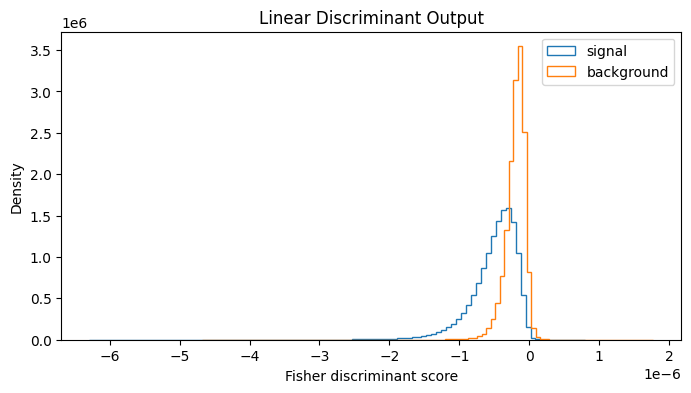

In [52]:
F_sig = X_sig @ w
F_bkg = X_bkg @ w

plt.figure(figsize=(8, 4))
plt.hist(F_sig, bins=100, histtype="step", density=True, label="signal")
plt.hist(F_bkg, bins=100, histtype="step", density=True, label="background")
plt.xlabel("Fisher discriminant score")
plt.ylabel("Density")
plt.title("Linear Discriminant Output")
plt.legend()
plt.show()

/var/folders/87/2ddmhzmx6hj6hwln8h1zcyhc0000gn/T/ipykernel_31083/1762105706.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(TPR, FPR)


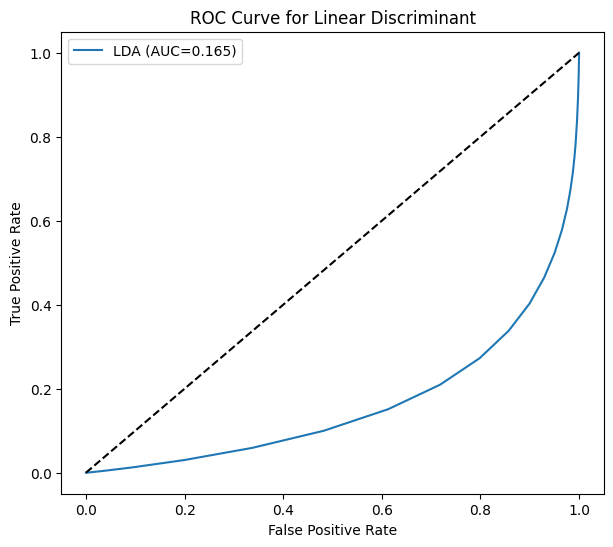

In [53]:
FPR, TPR, auc = roc_curve_manual(F_sig, F_bkg, "greater")

plt.figure(figsize=(7,6))
plt.plot(FPR, TPR, label=f"LDA (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Linear Discriminant")
plt.legend()
plt.show()

**LDA interpretation**

LDA combines all observables into a single linear score chosen to maximize class separation relative to the within-class spread.  
If the LDA ROC AUC is larger than the best single-variable AUC, that is evidence that combining variables captures useful information beyond any one cut alone.

In [54]:
def scan_discriminant(sig_vals, bkg_vals, N_sig, N_bkg, ncuts=300):
    xmin = min(np.min(sig_vals), np.min(bkg_vals))
    xmax = max(np.max(sig_vals), np.max(bkg_vals))
    cuts = np.linspace(xmin, xmax, ncuts)

    best_sig = -1
    best_cut = None

    for c in cuts:
        eps_s = np.mean(sig_vals > c)
        eps_b = np.mean(bkg_vals > c)
        sig = significance(eps_s, eps_b, N_sig, N_bkg)
        if sig > best_sig:
            best_sig = sig
            best_cut = c

    return best_cut, best_sig

In [55]:
for name, (N_sig, N_bkg) in scenarios.items():
    best_cut, best_sig = scan_discriminant(F_sig, F_bkg, N_sig, N_bkg)
    print(name, "best cut =", best_cut, "best sigma =", best_sig)

1 best cut = -6.287825673615854e-06 best sigma = 0.9534621914343075
2 best cut = -6.287825673615854e-06 best sigma = 3.015112187787897
2.1 best cut = -6.287825673615854e-06 best sigma = 4.2640125480460584
2.2 best cut = -6.287825673615854e-06 best sigma = 5.2223274997687925
2.3 best cut = -6.287825673615854e-06 best sigma = 6.030224375575794
2.4 best cut = -6.287825673615854e-06 best sigma = 6.741995811681849
3 best cut = -6.287825673615854e-06 best sigma = 9.534621914343075
4 best cut = -6.287825673615854e-06 best sigma = 30.15112187787897


The linear discriminant usually outperforms most single observables because it uses a weighted combination of all features instead of discarding information.  
A strong final discussion should compare:  
1. the best single-variable cut,  
2. the multi-cut strategy, and  
3. the LDA result.

Linear Discriminant Analysis (LDA)

LDA finds the linear combination of observables that best separates the signal and background classes.  
It does this by maximizing the distance between the class means while minimizing the spread of each class around its own mean.  
In this lab, that gives a one-dimensional discriminant score that can be treated just like another powerful observable.

### Linear Discriminant Analysis (LDA)

This finds a linear combination of variables that best separates signal and background. It works by maximizing the distance between class means (between-class variance) while minimizing the spread within each class (within-class variance).

## Conclusion

In this lab, we had to explore different methods for distinguishing signal from background events. Individual variable cuts provide a simple way to separate data but may not fully capture some relationships. ROC curves helped us compare the effectiveness of different variables. LDA improved performance by combining multiple variables into a single discriminant. Overall, as I went through the lab I found that multivariate methods such as LDA provide better separation compared to simple cut-based approaches.